In [3]:
from langgraph.graph import START,END, StateGraph
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

In [4]:
load_dotenv()

True

In [5]:
llm = ChatGroq(
    model = 'openai/gpt-oss-120b'
)


In [6]:
class ReviewSchema(BaseModel):
    sentiment: Literal['positve', 'negative'] = Field(description="Review of a sentiment")
    

In [7]:
structured_model = llm.with_structured_output(ReviewSchema)

In [41]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal['UX','bug','user','others'] = Field(description="Issue type of a sentiment")
    tone: Literal['polite','happy','angry','very angry'] = Field(description="Tone of a sentiment")
    urgency: Literal['low','medium','high'] = Field(description="Urgency of a sentiment")

In [42]:
structured_model2 = llm.with_structured_output(DiagnosisSchema)

In [10]:
prompt = f"Write the sentiment of the review - The product was too good to have"
output = structured_model.invoke(prompt)

In [11]:
output

ReviewSchema(sentiment='positve')

In [20]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive','negative']
    diagnosis: dict
    response: str

In [ ]:
def find_sentiment(state: ReviewState):
    prompt = f"You are en expert in sentiment analysis. Write the sentiment of the review - {state['review']}"

    sentiment = structured_model.invoke(prompt)
    return {"sentiment" : sentiment}

In [ ]:
def positive_response(state: ReviewState):
    prompt = f"Write a warm thank you message in response of the review - {state['review']}"
    return {'response' : llm.invoke(prompt).content}

def run_diag(state: ReviewState):
    prompt = f"Run a diagnosis over the review: {state['review']}. The return type should be issue_type, tone, urgency"
    output = structured_model2.invoke(prompt)
    return {'diagnosis': output.model_dump()}

def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']
    
    prompt = f"You are a support assistant. The user had {diagnosis['issue_type']} issue and with {diagnosis['urgency']} urgency. Write a empathyfull  message to this review - {state['review']}"
    response = llm.invoke(prompt)
    
    return {'response': response} 

In [44]:
def check_sentiment(state: ReviewState) -> Literal['run_diag', 'positive_response']:
    if state['sentiment'] == "positive":
        return 'positive_response'
    else:
        return "run_diag"

In [47]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diag", run_diag)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_sentiment)
graph.add_edge("positive_response", END)
graph.add_edge("run_diag", "negative_response")
graph.add_edge("negative_response", END)

workflow = graph.compile()

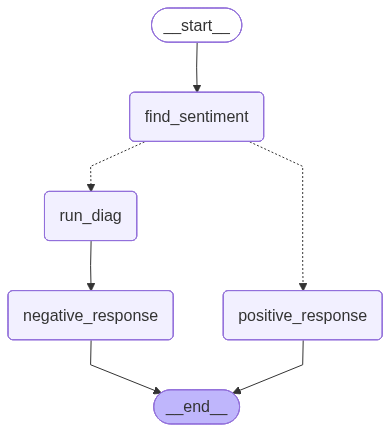

In [48]:
workflow 

In [53]:
initial_state = {
    "review" : "Got this beauty on Dec 23. Upgraded from iqoo3( yes, the first iqoo phone in India) after almost 5 years. Must say the previous one really held its ground.Coming back to 15r, this is pretty good upgrade as I am not very frequent camera user and gaming was my major priority. This phone really delivers on that front. Performance is smooth and you can get 110-115 avg fps in bgmi. Battery at 7400 mah is a really good, no complaints there. Camera is pretty good as well for the price. It has the same primary camera as the oneplus 15. Gives amazing results in daylight. If you know a little about photography then you can make a good use of this camera as well. UI is smooth and haptics are a little weak but not a deal breaker. Overall this phone is bang for the buck. I did consider waiting for the new iqoo neo 11 but the UI has lots of ads and I wanted a little cleaner experience. Go for it, as new phones are going to get pricey anyway."
}

final_state = workflow.invoke(initial_state)


In [54]:
final_state

{'review': 'Got this beauty on Dec 23. Upgraded from iqoo3( yes, the first iqoo phone in India) after almost 5 years. Must say the previous one really held its ground.Coming back to 15r, this is pretty good upgrade as I am not very frequent camera user and gaming was my major priority. This phone really delivers on that front. Performance is smooth and you can get 110-115 avg fps in bgmi. Battery at 7400 mah is a really good, no complaints there. Camera is pretty good as well for the price. It has the same primary camera as the oneplus 15. Gives amazing results in daylight. If you know a little about photography then you can make a good use of this camera as well. UI is smooth and haptics are a little weak but not a deal breaker. Overall this phone is bang for the buck. I did consider waiting for the new iqoo neo 11 but the UI has lots of ads and I wanted a little cleaner experience. Go for it, as new phones are going to get pricey anyway.',
 'sentiment': ReviewSchema(sentiment='positv